In [1]:
# Import numerical and tabular libraries for data handling
import numpy as np
import pandas as pd

# Import plotting libraries for quick visual checks
import matplotlib.pyplot as plt
import seaborn as sns

# Import train-test split and cross-validation tools
from sklearn.model_selection import train_test_split, KFold, cross_val_score

# Import preprocessing blocks for numeric and categorical features
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures

# Import Lasso models and evaluation metrics
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error

# Set display options so audit tables are easier to read
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

In [3]:

dataset_path = '../Preprocessed_dataset_knn(5neighbour).csv'

df = pd.read_csv(dataset_path)

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Convert date string to datetime so we can engineer date-based features
if 'Project Completion Date' in df.columns:
    df['Project Completion Date'] = pd.to_datetime(df['Project Completion Date'], errors='coerce')

df.head()

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Year Home Built,Size Of Home,Number Of Units,Job Type,Type Of Dwelling,Measure Type,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home
0,Broome,Endicott,New York State Electric & Gas,New York State Electric & Gas,9661.0,Oil,1973,1484,1,Home Performance,Single Family,Building Shell,277.0,24.0,6.826545,0,42.110115,-76.032545,2023,6,22,50
1,Queens,Queens,National Grid,Consolidated Edison,11867.0,Natural Gas,1933,1664,1,Home Performance,Single Family,Building Shell,1062.0,66.0,7.221105,0,40.697715,-73.786045,2023,6,22,90
2,Oswego,Fulton,National Grid,National Grid,9998.0,Natural Gas,1944,1252,1,Home Performance,Single Family,Building Shell,59.0,60.0,6.489205,0,43.325035,-76.411740,2023,6,20,79
3,St. Lawrence,Nicholville,Saint Lawrence Gas,National Grid,6880.0,Oil,1914,1700,1,Home Performance,Single Family,Building Shell,482.0,15.0,6.445720,0,44.695165,-74.704765,2023,6,13,109
4,Oswego,Cleveland,National Grid,National Grid,12289.0,Oil,1891,2680,1,Home Performance,Single Family,Building Shell,690.0,78.0,7.490529,0,43.231255,-75.868192,2023,6,13,132


In [4]:
# Target variable
target = 'First Year Modeled Project Energy Savings $ Estimate'

# Force target to numeric to avoid hidden string artifacts
df[target] = pd.to_numeric(df[target], errors='coerce')

# Build a sanity-check dictionary to validate data cleanliness before modeling
sanity_checks = {
    'rows': int(df.shape[0]),
    'columns': int(df.shape[1]),
    'duplicate_rows': int(df.duplicated().sum()),
    'missing_target': int(df[target].isna().sum()),
    'target_zero_count': int((df[target] == 0).sum()),
    'target_negative_count': int((df[target] < 0).sum()),
    'negative_kwh_count': int((pd.to_numeric(df['Estimated Annual kWh Savings'], errors='coerce') < 0).sum()),
    'negative_mmbtu_count': int((pd.to_numeric(df['Estimated Annual MMBtu Savings'], errors='coerce') < 0).sum())
}

# Convert checks to a one-row table for clean display
sanity_df = pd.DataFrame([sanity_checks])
sanity_df

,rows,columns,duplicate_rows,missing_target,target_zero_count,target_negative_count,negative_kwh_count,negative_mmbtu_count
0,51867,22,3,0,27,0,1156,120


In [10]:
# Quick column understanding table to inspect each feature before modeling
column_profile = pd.DataFrame({
    'column': df.columns,
    'dtype': [str(dt) for dt in df.dtypes],
    'missing_pct': df.isna().mean().mul(100).round(2).values,
    'n_unique': df.nunique(dropna=False).values
}).sort_values(['dtype', 'missing_pct'], ascending=[True, False]).reset_index(drop=True)

column_profile

,column,dtype,missing_pct,n_unique
0,Total Project Cost,float64,0.0,14230
1,Estimated Annual kWh Savings,float64,0.0,3665
2,Estimated Annual MMBtu Savings,float64,0.0,296
3,First Year Modeled Project Energy Savings $ Es...,float64,0.0,2302
4,Location_1_latitude,float64,0.0,1757
5,Location_1_Longitude,float64,0.0,1755
6,Year Home Built,int64,0.0,216
7,Size Of Home,int64,0.0,2653
8,Number Of Units,int64,0.0,41
9,size_of_home_flag,int64,0.0,1


In [5]:
# Keep only rows where target is available to avoid training on null labels
model_df = df[df[target].notna()].copy()

# Feature engineering to capture non-linear signal and useful ratios
if 'Total Project Cost' in model_df.columns and 'Size Of Home' in model_df.columns:
    model_df['cost_per_sqft'] = model_df['Total Project Cost'] / model_df['Size Of Home'].replace(0, np.nan)
if 'Total Project Cost' in model_df.columns and 'Number Of Units' in model_df.columns:
    model_df['cost_per_unit'] = model_df['Total Project Cost'] / model_df['Number Of Units'].replace(0, np.nan)
if 'Estimated Annual kWh Savings' in model_df.columns and 'Total Project Cost' in model_df.columns:
    model_df['kwh_per_dollar'] = model_df['Estimated Annual kWh Savings'] / model_df['Total Project Cost'].replace(0, np.nan)
if 'Estimated Annual MMBtu Savings' in model_df.columns and 'Total Project Cost' in model_df.columns:
    model_df['mmbtu_per_dollar'] = model_df['Estimated Annual MMBtu Savings'] / model_df['Total Project Cost'].replace(0, np.nan)

# Log transforms for skewed positive variables
for col in ['Total Project Cost', 'Size Of Home', 'Age of Home']:
    if col in model_df.columns:
        clipped = pd.to_numeric(model_df[col], errors='coerce').clip(lower=0)
        model_df[f'log1p_{col.replace(" ", "_")}'] = np.log1p(clipped)

# Remove leakage and identifier columns from features
drop_cols = [target, 'Project ID', 'Project Completion Date', 'Reporting Period']
X = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns], errors='ignore')
y = model_df[target]

# Split columns by type
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

# Numeric branch: impute, normalize, and create interactions
numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False))
])

# Categorical branch: impute then encode with rare-category handling
categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=0.01))
])

# Combine both preprocessing branches into a single transformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

# Train-test split for unbiased evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fast LassoCV: reduced alpha grid + 3-fold CV
lasso_pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('lasso', LassoCV(
        alphas=np.logspace(-4, -1, 25),
        cv=3,
        random_state=42,
        max_iter=30000,
        n_jobs=-1
    ))
])

# Train model and predict
lasso_pipeline.fit(X_train, y_train)
test_pred = lasso_pipeline.predict(X_test)

# Holdout performance metrics
mse = mean_squared_error(y_test, test_pred)
scores = {
    'R2': float(r2_score(y_test, test_pred)),
    'MAE': float(mean_absolute_error(y_test, test_pred)),
    'RMSE': float(np.sqrt(mse)),
    'Median_AE': float(median_absolute_error(y_test, test_pred)),
    'Chosen_Alpha': float(lasso_pipeline.named_steps['lasso'].alpha_)
}

# Quick CV with fixed alpha (avoids slow nested CV)
best_alpha = float(lasso_pipeline.named_steps['lasso'].alpha_)
quick_lasso_pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('lasso', Lasso(alpha=best_alpha, max_iter=30000))
])

cv = KFold(n_splits=3, shuffle=True, random_state=42)
cv_r2 = cross_val_score(quick_lasso_pipeline, X, y, cv=cv, scoring='r2', n_jobs=-1)
cv_rmse = np.sqrt(-cross_val_score(quick_lasso_pipeline, X, y, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1))

scores['CV_R2_Mean'] = float(cv_r2.mean())
scores['CV_R2_Std'] = float(cv_r2.std())
scores['CV_RMSE_Mean'] = float(cv_rmse.mean())
scores['CV_RMSE_Std'] = float(cv_rmse.std())

# Display score table
scores_df = pd.DataFrame([scores])
scores_df

,R2,MAE,RMSE,Median_AE,Chosen_Alpha,CV_R2_Mean,CV_R2_Std,CV_RMSE_Mean,CV_RMSE_Std
0,0.811513,0.232586,0.381881,0.159519,0.023714,0.765744,0.060452,0.42033,0.053299


In [6]:
# Extract transformed feature names after one-hot encoding
feature_names = lasso_pipeline.named_steps['prep'].get_feature_names_out()

# Extract Lasso coefficients aligned with transformed features
coefficients = lasso_pipeline.named_steps['lasso'].coef_

# Build coefficient table and keep only selected (non-zero) features
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefficients})
selected_features = coef_df[coef_df['coef'] != 0].copy()
selected_features['abs_coef'] = selected_features['coef'].abs()
selected_features = selected_features.sort_values('abs_coef', ascending=False)

# Show selected feature count and top drivers
print('Selected non-zero features:', selected_features.shape[0])
selected_features[['feature', 'coef']].head(15)

Selected non-zero features: 22


,feature,coef
17,num__log1p_Total_Project_Cost,0.613278
259,cat__Pre-Retrofit Home Heating Fuel Type_Natur...,-0.375924
16,num__mmbtu_per_dollar,0.240084
15,num__kwh_per_dollar,0.190725
5,num__Estimated Annual MMBtu Savings,0.188408
8,num__Location_1_Longitude,0.087607
7,num__Location_1_latitude,-0.068060
200,num__kwh_per_dollar mmbtu_per_dollar,-0.033206
4,num__Estimated Annual kWh Savings,0.031770
9,num__Project Completion Year,-0.029946


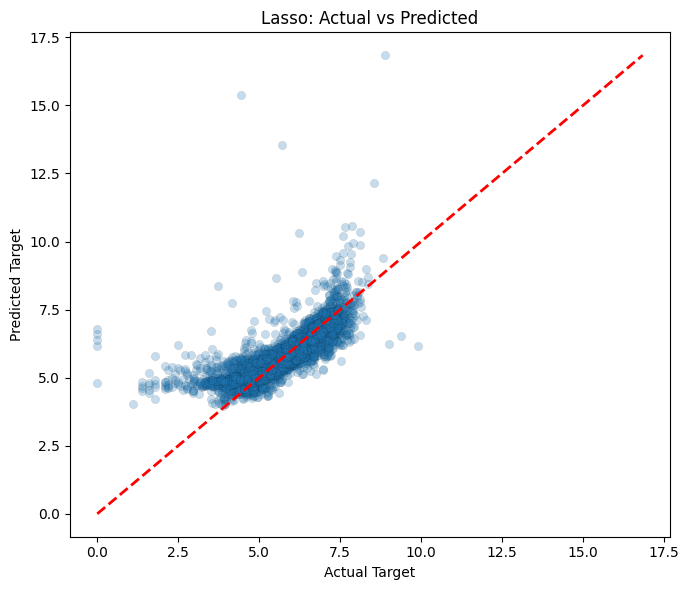

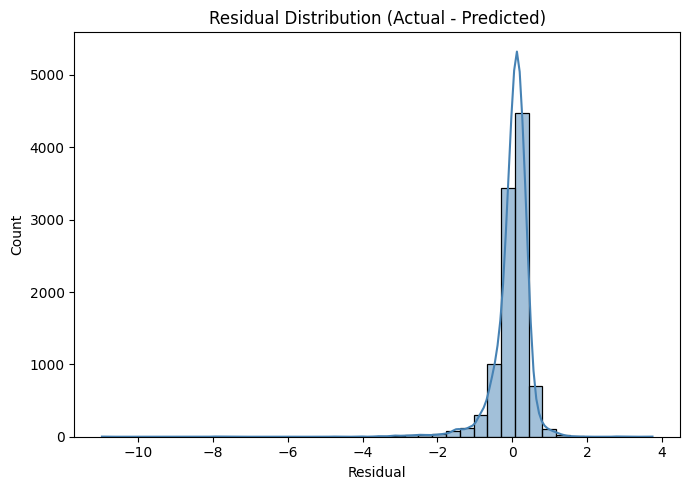

In [ ]:

plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_pred, alpha=0.25, edgecolor='black', linewidth=0.2)

line_min = float(min(y_test.min(), test_pred.min()))
line_max = float(max(y_test.max(), test_pred.max()))
plt.plot([line_min, line_max], [line_min, line_max], color='red', linestyle='--', linewidth=2)

plt.title('Lasso: Actual vs Predicted')
plt.xlabel('Actual Target')
plt.ylabel('Predicted Target')
plt.tight_layout()
plt.show()

residuals = y_test - test_pred
plt.figure(figsize=(7, 5))
sns.histplot(residuals, bins=40, kde=True, color='steelblue')
plt.title('Residual Distribution (Actual - Predicted)')
plt.xlabel('Residual')
plt.tight_layout()
plt.show()

## Findings From Updated Run

Using the updated normalization + feature engineering setup, the latest run produced:
- Holdout R2: **0.8115**
- Holdout MAE: **0.2326**
- Holdout RMSE: **0.3819**
- Holdout Median AE: **0.1595**
- Chosen alpha: **0.023714**
- Cross-val R2 (mean +- std): **0.7657 +- 0.0605**
- Cross-val RMSE (mean +- std): **0.4203 +- 0.0533**
- Selected non-zero features: **22**

Compared to the initial run, model fit improved substantially after:
1. Better normalization and handling of numeric scale.
2. Feature engineering with ratio features and log transforms.
3. Interaction features for numeric variables.
4. Faster but still robust CV strategy (no nested expensive loops).